# Visualizing MESA reactions

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
from pynucastro import mesa_utils
from pynucastro.screening import chugunov_2007

## Read in the MESA model

In [3]:
model = mr.MesaData("lab3/profile2.data")

In [4]:
nuclei = mesa_utils.get_nuclei(model)

In [6]:
mesa_zones = mesa_utils.MesaModel(model)

## Create the network using the same species as the MESA model

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [7]:
net = pyna.network_helper(nuclei)

In [8]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  branched rates: 0
  modified rates: 0
  custom rates: 0


We can see the structure of the network

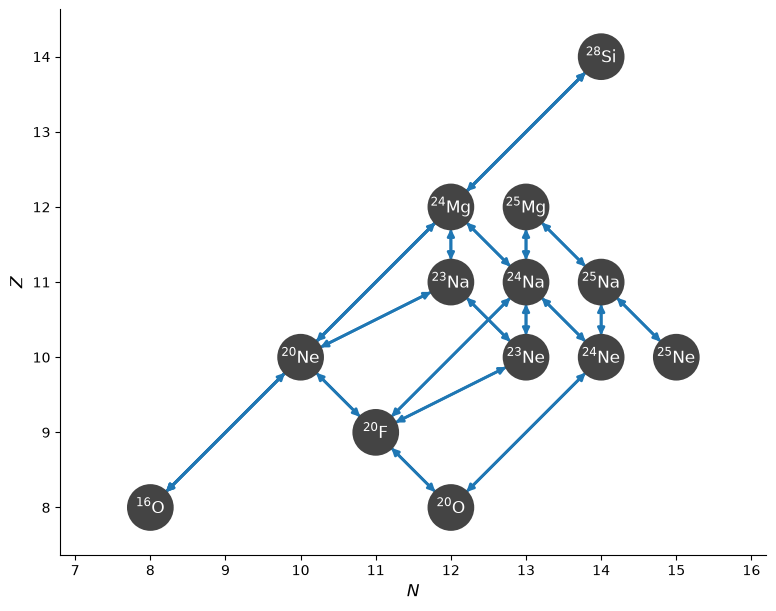

In [9]:
fig = net.plot()

The Suzuki rates are not valid for $\rho Y_e < 10^7~\mathrm{g~cm^{-3}}$, so let's find the model index that corresponds to

In [11]:
type(mesa_zones)

pynucastro.mesa_utils.MesaModel

In [12]:
i_cutoff = -1
for i in range(len(mesa_zones.mesa_zones)):
    state = mesa_zones.get_zone_data(i)
    rhoye = state.rho * state.comp.ye
    if rhoye > 1.e7:
        i_cutoff = i
        break

In [13]:
i_cutoff

298

## A network plot

Here's a function that takes a zone index from the MESA model and makes a plot showing both the flow through the network at that zone and the entire MESA model in the log $\rho$-log T plane, with a point indicated the zone we are visualizing.

In [17]:
import matplotlib.pyplot as plt

In [14]:
rhos = mesa_zones.get_data_array("rho")
Ts = mesa_zones.get_data_array("T")

In [24]:
def _make_plot(i_zone, curved_edges=False, legend=False):
    fig = plt.figure()
    fig.set_layout_engine("constrained")
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1])
    gs_net = gs[0].subgridspec(2, 2, width_ratios=[20, 1])
    ax_rhoT = fig.add_subplot(gs[1])
    if curved_edges:
        use_net_rate = False
    else:
        use_net_rate = True
    if legend:
        legend_coord = (11.5, 8.5)
    else:
        legend_coord = None
    state = mesa_zones.get_zone_data(i_zone)
    net.plot(state.rho, state.T, state.comp,
             screen_func=chugunov_2007,
             use_net_rate=use_net_rate, curved_edges=curved_edges,
             ydot_cutoff_value=1.e-30,
             legend_coord=legend_coord,
             show_small_ydot=True,
             grid_spec=gs_net,
             color_nodes_by_abundance=True)

    ax_rhoT.loglog(rhos, Ts)
    ax_rhoT.set_xlabel(r"$\rho$")
    ax_rhoT.set_ylabel("T")
    ax_rhoT.scatter([state.rho], [state.T], marker="o", color="C1")
    ax_rhoT.grid(ls=":")
    
    fig.text(0.1, 0.9, rf"T = {state.T:6.3g} K, $\rho$ = {state.rho:6.3g} g/cm$^3$", transform=fig.transFigure)
    fig.text(0.1, 0.925, f"zone = {i_zone}", transform=fig.transFigure)
    fig.set_size_inches(11, 6)

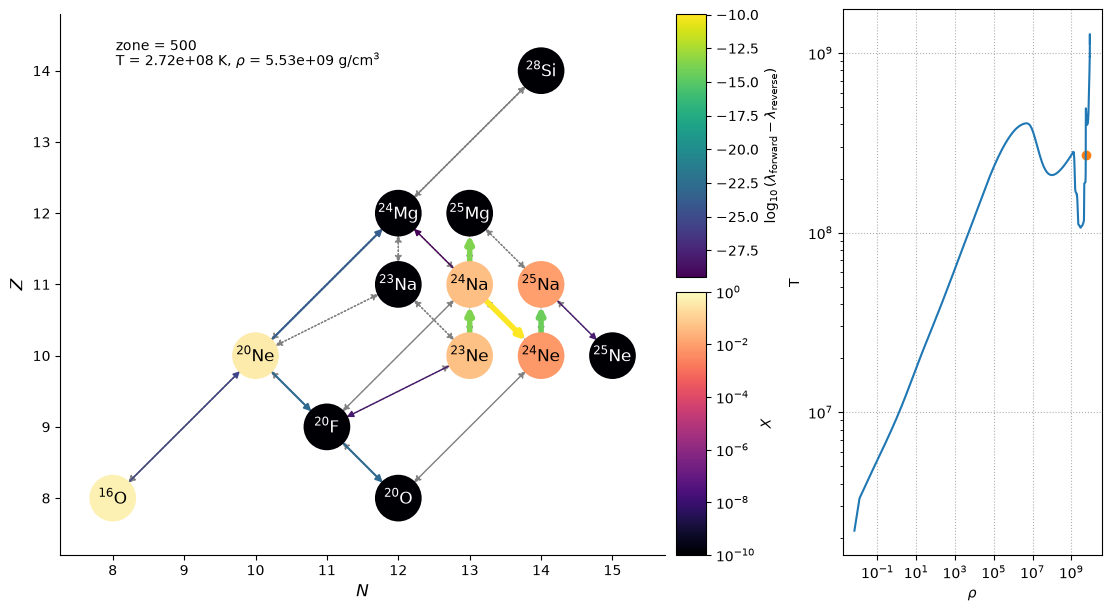

In [25]:
_make_plot(500)

## Interactive plot

We can make the plot interactive by using `ipywidgets`

In [26]:
from ipywidgets import interact

In [28]:
interact(_make_plot, i_zone=(i_cutoff, len(mesa_zones.mesa_zones)-1, 1), curved_edges=False)

interactive(children=(IntSlider(value=541, description='i_zone', max=785, min=298), Checkbox(value=False, desc…

<function __main__._make_plot(i_zone, curved_edges=False, legend=False)>